In [180]:
import pandas as pd
import glob
import numpy as np
import datetime as dt
from matplotlib import pyplot as plt

In [72]:
#Extracting household power consumption files
files_hp = glob.glob(r'./p1-power-weather/household_power_consumption/*.csv')
df_list = []
for file in files_hp:
    df = pd.read_csv(file, sep = ';', header = None, low_memory=False)
    df_list.append(df)
df_hp = pd.concat(df_list, ignore_index = True)
#Renaming columns
column_names = ['date','time','g_active_p','g_reactive_p','voltage','g_intensity','sub_meter1','sub_meter2','sub_meter3']
df_hp.columns = column_names

#Changing data types to numeric
df_hp[column_names[2:]] = df_hp[column_names[2:]].apply(pd.to_numeric, errors = "coerce")

#Changing date column type to date
df_hp['date']= pd.to_datetime(df_hp['date'])

#Changing time column type to time
df_hp['time']= pd.to_datetime(df_hp['time'], format = "%H:%M:%S").dt.strftime('%H:%M:%S')

In [73]:
df_hp

,date,time,g_active_p,g_reactive_p,voltage,g_intensity,sub_meter1,sub_meter2,sub_meter3
0,2010-01-01,00:00:00,1.790,0.236,240.65,7.4,0.0,0.0,18.0
1,2010-01-01,00:01:00,1.780,0.234,240.07,7.4,0.0,0.0,18.0
2,2010-01-01,00:02:00,1.780,0.234,240.15,7.4,0.0,0.0,19.0
3,2010-01-01,00:03:00,1.746,0.186,240.26,7.2,0.0,0.0,18.0
4,2010-01-01,00:04:00,1.686,0.102,240.12,7.0,0.0,0.0,18.0
...,...,...,...,...,...,...,...,...,...
2053258,2008-12-31,23:55:00,0.484,0.064,247.69,2.2,0.0,0.0,0.0
2053259,2008-12-31,23:56:00,0.482,0.064,247.35,2.2,0.0,0.0,0.0
2053260,2008-12-31,23:57:00,0.482,0.064,246.99,2.2,0.0,0.0,0.0
2053261,2008-12-31,23:58:00,0.480,0.064,246.52,2.2,0.0,0.0,0.0


In [75]:
df_hp.dtypes

date            datetime64[ns]
time                    object
g_active_p             float64
g_reactive_p           float64
voltage                float64
g_intensity            float64
sub_meter1             float64
sub_meter2             float64
sub_meter3             float64
dtype: object

In [171]:
#Extracting weather files
files_w = glob.glob(r'./p1-power-weather/weather/*.csv')
files_w.remove(r'./p1-power-weather/weather/postesSynop.csv')
df_list = []
lengths = []
for file in files_w:
    df2 = pd.read_csv(file, sep = ';', header = 0)
    df_list.append(df2)
    #df_list.append(df2[df2["numer_sta"] == 7149]) Plus rapide?
    lengths.append(len(df2))
df_w = pd.concat(df_list, ignore_index = True)
df_w=df_w[df_w["numer_sta"] == 7149]

#Transforming to numeric
columns_names = df_w.columns
for col in columns_names[2:]:
    df_w[col] = pd.to_numeric(df_w[col], errors="coerce")

#Removing columns with too many NaN values
df_w=df_w.dropna(axis = 1, thresh= 11000)

#Interpolating missing values
df_w=df_w.interpolate(method='linear',axis=1)

#Fixing date and time
df_w['date'] = pd.to_datetime((df_w['date'].astype(int)).astype(str))


In [172]:
df_w

,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,pres,rafper,per,ssfrai,perssfrai,rr1,rr3,phenspe1,phenspe2,phenspe3
9,7149.0,2008-08-01 00:00:00,101220.0,50.0,0.0,230.0,4.1,294.05,291.25,84.0,...,100180.0,7.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1107.0,3100.0
67,7149.0,2008-08-01 03:00:00,101460.0,220.0,1.0,250.0,7.2,290.85,287.95,83.0,...,100400.0,11.8,-10.0,0.0,-30.0,0.0,0.0,710.0,1112.0,3100.0
126,7149.0,2008-08-01 06:00:00,101690.0,220.0,2.0,240.0,4.1,289.65,286.75,83.0,...,100620.0,7.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1107.0,3100.0
185,7149.0,2008-08-01 09:00:00,101800.0,120.0,1.0,240.0,5.1,292.05,286.05,68.0,...,100740.0,8.7,-10.0,0.0,-30.0,0.0,0.0,710.0,1109.0,3100.0
244,7149.0,2008-08-01 12:00:00,101790.0,10.0,0.0,220.0,6.2,296.05,285.35,51.0,...,100750.0,9.8,-10.0,0.0,-60.0,0.0,0.0,710.0,1110.0,3100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678922,7149.0,2008-03-31 09:00:00,101460.0,130.0,3.0,180.0,4.1,280.85,279.15,89.0,...,100360.0,7.2,-10.0,0.0,-30.0,0.0,0.0,710.0,1107.0,3100.0
678978,7149.0,2008-03-31 12:00:00,101640.0,190.0,1.0,230.0,3.1,283.15,279.85,80.0,...,100550.0,6.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1106.0,3100.0
679035,7149.0,2008-03-31 15:00:00,101740.0,110.0,3.0,0.0,0.0,286.35,279.65,64.0,...,100660.0,3.1,-10.0,0.0,-30.0,0.0,0.8,710.0,1103.0,3100.0
679095,7149.0,2008-03-31 18:00:00,101970.0,220.0,3.0,250.0,2.1,284.75,278.65,66.0,...,100880.0,6.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1106.0,3100.0


In [177]:
#Creating date + time column

#df_w['ymd'] = df_w['date'].apply(date)
df_w['time'] =  df_w['date'].apply(lambda x:x.time())
df_w['date'] = df_w['date'].apply(lambda x:x.date())

In [178]:
df_w

,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,rafper,per,ssfrai,perssfrai,rr1,rr3,phenspe1,phenspe2,phenspe3,time
9,7149.0,2008-08-01,101220.0,50.0,0.0,230.0,4.1,294.05,291.25,84.0,...,7.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1107.0,3100.0,00:00:00
67,7149.0,2008-08-01,101460.0,220.0,1.0,250.0,7.2,290.85,287.95,83.0,...,11.8,-10.0,0.0,-30.0,0.0,0.0,710.0,1112.0,3100.0,03:00:00
126,7149.0,2008-08-01,101690.0,220.0,2.0,240.0,4.1,289.65,286.75,83.0,...,7.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1107.0,3100.0,06:00:00
185,7149.0,2008-08-01,101800.0,120.0,1.0,240.0,5.1,292.05,286.05,68.0,...,8.7,-10.0,0.0,-30.0,0.0,0.0,710.0,1109.0,3100.0,09:00:00
244,7149.0,2008-08-01,101790.0,10.0,0.0,220.0,6.2,296.05,285.35,51.0,...,9.8,-10.0,0.0,-60.0,0.0,0.0,710.0,1110.0,3100.0,12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678922,7149.0,2008-03-31,101460.0,130.0,3.0,180.0,4.1,280.85,279.15,89.0,...,7.2,-10.0,0.0,-30.0,0.0,0.0,710.0,1107.0,3100.0,09:00:00
678978,7149.0,2008-03-31,101640.0,190.0,1.0,230.0,3.1,283.15,279.85,80.0,...,6.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1106.0,3100.0,12:00:00
679035,7149.0,2008-03-31,101740.0,110.0,3.0,0.0,0.0,286.35,279.65,64.0,...,3.1,-10.0,0.0,-30.0,0.0,0.8,710.0,1103.0,3100.0,15:00:00
679095,7149.0,2008-03-31,101970.0,220.0,3.0,250.0,2.1,284.75,278.65,66.0,...,6.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1106.0,3100.0,18:00:00


In [169]:
date = list(df_w['date'])
A = str(int(date[2]))
B = pd.to_datetime(str(int(date[2423])))
print(B)
print(B.time())

2009-08-31 09:00:00
09:00:00


In [153]:
pd.to_datetime((df_w['date'].astype(int)).astype(str))

9        2008-08-01 00:00:00
67       2008-08-01 03:00:00
126      2008-08-01 06:00:00
185      2008-08-01 09:00:00
244      2008-08-01 12:00:00
                 ...        
678922   2008-03-31 09:00:00
678978   2008-03-31 12:00:00
679035   2008-03-31 15:00:00
679095   2008-03-31 18:00:00
679155   2008-03-31 21:00:00
Name: date, Length: 11656, dtype: datetime64[ns]

In [181]:
def plot_daily_consumption(df):
  n = len(df)
  daily_c = []
  daily_mean= (df['g_active_p'][0])
  for i in range(1,n):
    if i%(24*60)==0:
      daily_c.append(daily_mean/(24*60))
      daily_mean=0
    daily_mean += (df['g_active_p'][i])
  plt.figure(figsize=(15,7))
  
  plt.plot(np.arange(len(daily_c[0:365])),daily_c[0:365])
  plt.axvline(x = 80,color='r') #start spring
  plt.axvline(x=170,color='r')  #start summer
  plt.axvline(x=260,color='r') #end summer
  plt.show()

  return daily_c

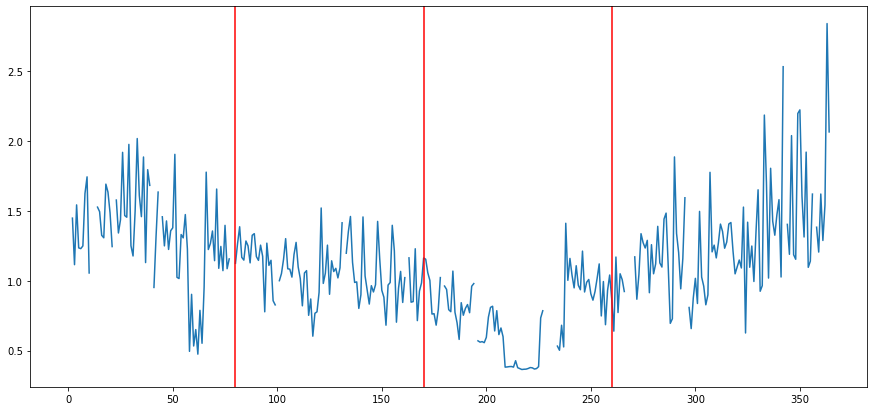

In [182]:
daily_c = plot_daily_consumption(df_hp)